In [1]:
# Load the necessary libraries
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from timm import create_model
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Hyperparameters
batch_size = 16
num_classes = 2  # Binary classification: IED vs Real Waste
image_size = 224
num_workers = 0  # Disable multiprocessing

In [3]:
class CombinedDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error loading image {self.image_paths[idx]}: {str(e)}")
            return None

In [4]:
def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return images, labels

In [5]:
def load_test_data(base_dir):
    ied_dir = os.path.join(base_dir, 'ied_data', 'test')
    trashnet_dir = os.path.join(base_dir, 'trashnet_data')

    ied_paths = glob.glob(os.path.join(ied_dir, '*.*'))
    ied_labels = [0] * len(ied_paths)  # 0 for IED

    trashnet_paths = []
    trashnet_labels = []
    
    for category in os.listdir(trashnet_dir):
        category_path = os.path.join(trashnet_dir, category)
        if os.path.isdir(category_path):
            category_images = glob.glob(os.path.join(category_path, '*.*'))
            trashnet_paths.extend(category_images)
            trashnet_labels.extend([1] * len(category_images))  # 1 for Real Waste

    all_paths = ied_paths + trashnet_paths
    all_labels = ied_labels + trashnet_labels

    return all_paths, all_labels

Starting the binary waste detection evaluation...
Loading test data...
Setting up data transforms...
Creating test dataset...
Loading Vision Transformer model...


C:\Users\nisin\AppData\Local\Temp\ipykernel_3380\2878107813.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_waste_detection_model

Evaluating on test set...
Calculating metrics...
Overall Metrics:
Test Accuracy: 0.9984
Precision: 0.9986
Recall: 0.9984
F1 Score: 0.9985

Per-Category Metrics:

IED:
Precision: 0.8667
Recall: 1.0000
F1 Score: 0.9286

Real Waste:
Precision: 1.0000
Recall: 0.9984
F1 Score: 0.9992

Plotting confusion matrix...


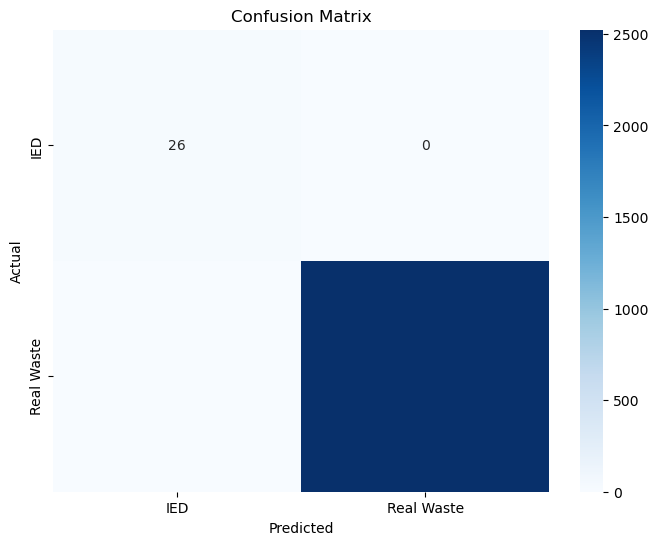

Evaluation completed successfully.


In [6]:
# Main execution
if __name__ == "__main__":
    try:
        print("Starting the binary waste detection evaluation...")

        base_dir = r'C:\Users\nisin\OneDrive\Documents\MIT\MDA522 Artificial Intelligence\Assignments\Assignment 2'

        print("Loading test data...")
        test_paths, test_labels = load_test_data(base_dir)

        print("Setting up data transforms...")
        transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        print("Creating test dataset...")
        test_dataset = CombinedDataset(test_paths, test_labels, transform)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

        print("Loading Vision Transformer model...")
        model = create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
        model.load_state_dict(torch.load('best_waste_detection_model_vit_binary.pth'))
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = model.to(device)
        model.eval()

        print("Evaluating on test set...")
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in test_loader:
                if batch is None:
                    continue
                images, labels = batch
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print("Calculating metrics...")
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
        conf_matrix = confusion_matrix(all_labels, all_preds)

        print("Overall Metrics:")
        print(f'Test Accuracy: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1 Score: {f1:.4f}')

        # Per-category metrics
        class_names = ['IED', 'Real Waste']
        per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

        print("\nPer-Category Metrics:")
        for i, class_name in enumerate(class_names):
            print(f"\n{class_name}:")
            print(f'Precision: {per_class_precision[i]:.4f}')
            print(f'Recall: {per_class_recall[i]:.4f}')
            print(f'F1 Score: {per_class_f1[i]:.4f}')

        print("\nPlotting confusion matrix...")
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        print("Evaluation completed successfully.")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()